<a href="https://colab.research.google.com/github/MuhamadRizki10R2/ML-Forecasting-Gold-Price/blob/main/ForecastingGoldPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project ML - Gold Price Forecasting**





## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from google.colab import files

## Load Dataset

In [2]:
warnings.filterwarnings('ignore')

# 3. Load & Format Data
df = pd.read_csv('gold_price_forecasting_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Drop 'adj close' karena duplikasi informasi dengan 'close'
if 'adj close' in df.columns:
    df.drop('adj close', axis=1, inplace=True)

print(f"\nDataset loaded successfully! Total rows: {len(df)}")


Dataset loaded successfully! Total rows: 1167


## Preprocessing Data (Splitting & Scaling)

In [3]:
# Tentukan Target dan Fitur
target_col = 'daily_return'
features = df.columns.tolist()

# Chronological Split (80% Train, 20% Test) - TANPA SHUFFLE
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Inisialisasi Scaler
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit HANYA pada data training, lalu transform seluruh data
feature_scaler.fit(train_df[features])
target_scaler.fit(train_df[[target_col]])

scaled_features = feature_scaler.transform(df[features])
scaled_target = target_scaler.transform(df[[target_col]])

print("Scaling selesai tanpa Data Leakage!")

Scaling selesai tanpa Data Leakage!


## Membuat Sequence (Time-Steps)

In [4]:
def create_sequences(features, target, look_back=60):
    X, y = [], []
    for i in range(look_back, len(features)):
        X.append(features[i-look_back:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_sequences(scaled_features, scaled_target, look_back)

# Split sequence yang sudah jadi
X_train, X_test = X[:split_index-look_back], X[split_index-look_back:]
y_train, y_test = y[:split_index-look_back], y[split_index-look_back:]

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")

Bentuk X_train: (873, 60, 16)
Bentuk X_test: (234, 60, 16)


## Membangun & Melatih Model LSTM

In [5]:
# Build Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1)) # Output prediksi return

model.compile(optimizer='adam', loss='mean_squared_error')

# Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print("Memulai Training LSTM...")
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=50,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)

Memulai Training LSTM...
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 222ms/step - loss: 1.0190 - val_loss: 3.0297
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - loss: 0.9981 - val_loss: 2.9861
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - loss: 1.0084 - val_loss: 2.9661
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.9874 - val_loss: 2.9655
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.9850 - val_loss: 2.9670
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.9921 - val_loss: 2.9679
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.9911 - val_loss: 2.9518
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.9764 - val_loss: 3.0200
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.9752 - val_loss: 2.9851
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.9842 - val_loss: 3.0223
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.9827 - val_loss: 3.0013
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━

## Prediksi, Eval, Visualisasi Hasil Akhir

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


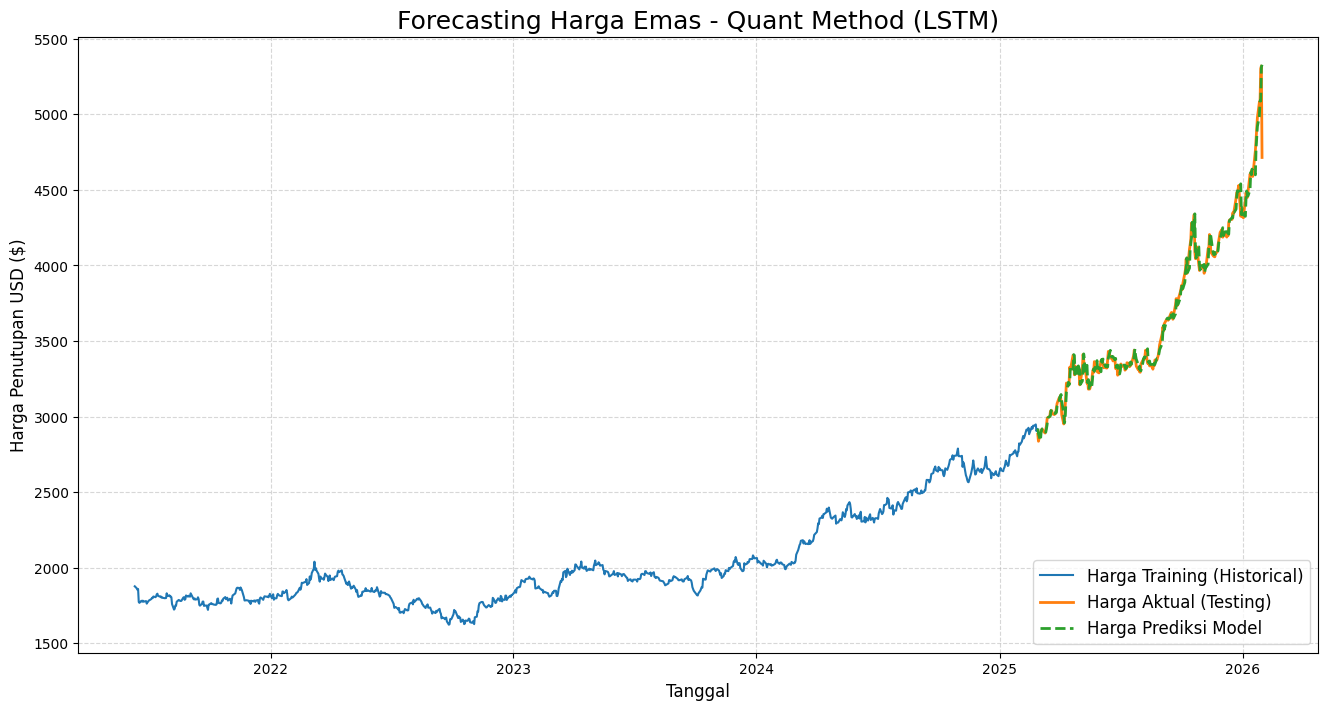

----------------------------------------
📊 HASIL EVALUASI MODEL
----------------------------------------
Mean Absolute Error (MAE)  : $39.64
Root Mean Squared Error (RMSE): $66.32
----------------------------------------


In [6]:
# Prediksi target (Daily Return)
pred_scaled_returns = model.predict(X_test)
pred_returns = target_scaler.inverse_transform(pred_scaled_returns)

# Rekonstruksi Harga ke USD
actual_close = test_df['close'].values
predicted_close_prices = []

for i in range(len(pred_returns)):
    if i == 0:
        prev_close = train_df['close'].iloc[-1]
    else:
        prev_close = actual_close[i-1] # 1-Step Ahead Forecasting

    pred_price = prev_close * (1 + pred_returns[i][0])
    predicted_close_prices.append(pred_price)

# Siapkan dataframe untuk visualisasi
valid_final = test_df.copy()
valid_final['Prediksi_Harga'] = predicted_close_prices

# Visualisasi Grafik
plt.figure(figsize=(16,8))
plt.title('Forecasting Harga Emas - Quant Method (LSTM)', fontsize=18)
plt.plot(train_df.index, train_df['close'], label='Harga Training (Historical)', color='#1f77b4', linewidth=1.5)
plt.plot(valid_final.index, valid_final['close'], label='Harga Aktual (Testing)', color='#ff7f0e', linewidth=2)
plt.plot(valid_final.index, valid_final['Prediksi_Harga'], label='Harga Prediksi Model', color='#2ca02c', linestyle='dashed', linewidth=2)

plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan USD ($)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Evaluasi Kinerja (Metrics)
mae = mean_absolute_error(valid_final['close'], valid_final['Prediksi_Harga'])
rmse = np.sqrt(mean_squared_error(valid_final['close'], valid_final['Prediksi_Harga']))

print("-" * 40)
print("📊 HASIL EVALUASI MODEL")
print("-" * 40)
print(f"Mean Absolute Error (MAE)  : ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print("-" * 40)

## Visualisasi Training Model

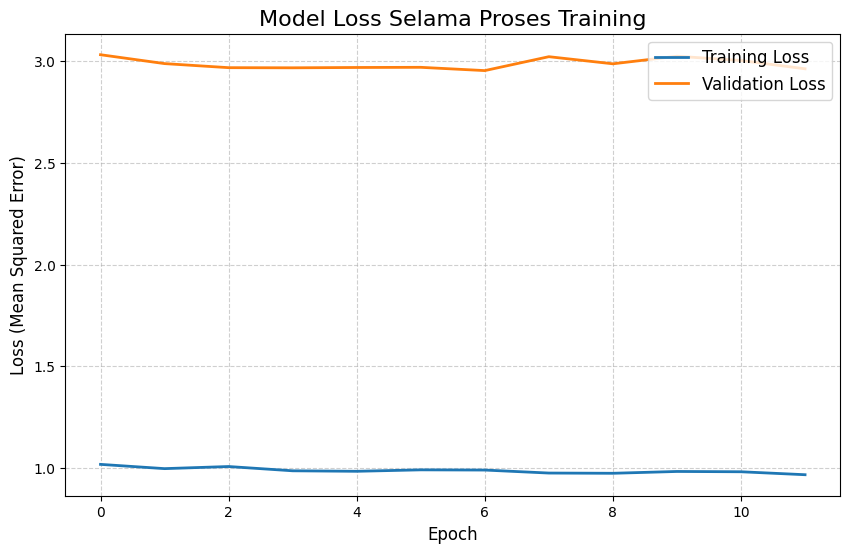

In [7]:
# Membuat visualisasi pergerakan Loss selama proses training
plt.figure(figsize=(10, 6))

# Plot training dan validation loss dari object 'history'
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)

# Kustomisasi tampilan grafik
plt.title('Model Loss Selama Proses Training', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Menampilkan grafik
plt.show()

## Simulasi Cek Prediksi Hari Terakhir

In [8]:
# Ambil angka prediksi return paling terakhir (baris terakhir dari array pred_returns)
latest_predicted_return = pred_returns[-1][0]

# Ambil harga asli di hari sebelumnya (untuk dikalikan)
# Karena index array mulai dari 0, data sebelum yang terakhir adalah index -2
prev_actual_price = valid_final['close'].iloc[-2]

# Ambil harga prediksi (hasil kali)
latest_predicted_price = valid_final['Prediksi_Harga'].iloc[-1]

# Ambil Tanggal terakhir
latest_date = valid_final.index[-1].strftime('%Y-%m-%d')

print("-" * 50)
print(f"📊 RINCIAN PREDIKSI UNTUK TANGGAL: {latest_date}")
print("-" * 50)

# Tampilkan Prediksi Return AI (Ubah ke Persentase)
persentase_return = latest_predicted_return * 100
if persentase_return > 0:
    arah = "NAIK 📈"
else:
    arah = "TURUN 📉"

print(f"1. AI Memprediksi Harga Akan : {arah}")
print(f"2. Nilai Prediksi Return AI  : {latest_predicted_return:.5f} (atau {persentase_return:.2f}%)")
print(f"3. Harga Asli Kemarin        : ${prev_actual_price:.2f}")
print("-" * 50)
print(f"RUMUS: ${prev_actual_price:.2f} * (1 + {latest_predicted_return:.5f})")
print(f"🎯 HARGA PREDIKSI HARI INI   : ${latest_predicted_price:.2f}")
print("-" * 50)

--------------------------------------------------
📊 RINCIAN PREDIKSI UNTUK TANGGAL: 2026-01-30
--------------------------------------------------
1. AI Memprediksi Harga Akan : NAIK 📈
2. Nilai Prediksi Return AI  : 0.00169 (atau 0.17%)
3. Harga Asli Kemarin        : $5318.40
--------------------------------------------------
RUMUS: $5318.40 * (1 + 0.00169)
🎯 HARGA PREDIKSI HARI INI   : $5327.39
--------------------------------------------------


## Menyimpan file Hasil Model

In [9]:
import joblib
from google.colab import files

# 1. Simpan Model LSTM (Format .h5 atau .keras)
model.save('gold_price_lstm_model.h5')
print("✅ Model LSTM berhasil disimpan sebagai 'gold_price_lstm_model.h5'")

# 2. Simpan Scaler (SANGAT PENTING!)
# Kita simpan agar saat ada data baru di masa depan, kita pakai skala yang sama.
joblib.dump(feature_scaler, 'feature_scaler.pkl')
joblib.dump(target_scaler, 'target_scaler.pkl')
print("✅ Scalers berhasil disimpan sebagai file .pkl")

# 3. Simpan Hasil Prediksi ke CSV
# Kita simpan tabel valid_final yang berisi Harga Aktual vs Harga Prediksi
valid_final.to_csv('gold_price_predictions_results.csv')
print("✅ Laporan Prediksi berhasil disimpan sebagai 'gold_price_predictions_results.csv'")

# 4. DOWNLOAD OTOMATIS KE KOMPUTER ANDA
# Jalankan ini jika Anda ingin file langsung terdownload dari Google Colab
print("\nMenyiapkan download...")
files.download('gold_price_lstm_model.h5')
files.download('feature_scaler.pkl')
files.download('target_scaler.pkl')
files.download('gold_price_predictions_results.csv')

✅ Model LSTM berhasil disimpan sebagai 'gold_price_lstm_model.h5'
✅ Scalers berhasil disimpan sebagai file .pkl
✅ Laporan Prediksi berhasil disimpan sebagai 'gold_price_predictions_results.csv'

Menyiapkan download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>